In [10]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, random, warnings, cv2, math, time, glob, base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from albumentations import Compose, Resize, ShiftScaleRotate, RandomBrightnessContrast, GaussianBlur, CoarseDropout, Lambda, Normalize
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# If your file name is different, change it here:
MODEL_PATH = "/content/siamese_best_model.pth"
assert os.path.exists(MODEL_PATH), f"Model file not found at {MODEL_PATH}. Upload your .pth to /content."


Mounted at /content/drive
Device: cuda


In [11]:
#  [2] Hyper-params & paths (kept consistent with your training notebook)
SHAPE_SOURCES = {
    "shape7":  ("/content/shape7_labels_all.csv", "/content/drive/MyDrive/shapes/shape7"),
    "shape9":  ("/content/shape9_scores.csv",     "/content/drive/MyDrive/shapes/shape9"),
    "shape14": ("/content/shape14_scores.xlsx",   "/content/drive/MyDrive/shapes/shape14"),
    "shape18": ("/content/shape18_scores.csv",    "/content/drive/MyDrive/shapes/shape18"),
}

IMG_SIZE   = 128
EMB_DIM    = 128
TOL        = 1

# Normalization expected by your ResNet (single channel)
NORM_MEAN = [0.485]
NORM_STD  = [0.229]


In [12]:
#  [3] Smart auto-crop + transforms (same behavior as training)
def smart_center_crop(img: np.ndarray, thr=20):
    ys, xs = np.where(img > thr)
    if xs.size == 0:
        return img
    x0, x1, y0, y1 = xs.min(), xs.max(), ys.min(), ys.max()
    side = max(x1 - x0, y1 - y0) + 2
    cx, cy = (x0 + x1)//2, (y0 + y1)//2
    half = side//2
    x0, x1, y0, y1 = cx-half, cx+half, cy-half, cy+half
    pad_x0, pad_y0 = max(-x0,0), max(-y0,0)
    pad_x1, pad_y1 = max(x1-img.shape[1]+1,0), max(y1-img.shape[0]+1,0)
    if pad_x0+pad_x1+pad_y0+pad_y1:
        img = np.pad(img, ((pad_y0,pad_y1),(pad_x0,pad_x1)), constant_values=0)
        y0+=pad_y0; y1+=pad_y0; x0+=pad_x0; x1+=pad_x0
    return img[y0:y1+1, x0:x1+1]

class SmartCrop:
    def __init__(self, thr=20): self.thr=thr
    def __call__(self, img, **kw): return smart_center_crop(img, self.thr)

val_tf = Compose([
    Lambda(image=SmartCrop(20)),
    Resize(IMG_SIZE, IMG_SIZE),
    Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2()
])


In [14]:
# [4] Build merged dataframe and resolve reference images
def load_all_shapes(shape_sources):
    frames = []
    for shape_name, (score_file, img_dir) in shape_sources.items():
        if score_file.lower().endswith((".xls", ".xlsx")):
            df_shape = pd.read_excel(score_file)
        else:
            df_shape = pd.read_csv(score_file, encoding="utf-8")
        df_shape["img_path"] = df_shape["child_id"].apply(lambda cid: os.path.join(img_dir, f"{cid}.png"))
        df_shape = df_shape[df_shape["img_path"].apply(os.path.exists)]
        df_shape["shape_name"] = shape_name
        df_shape["img_dir"] = img_dir
        frames.append(df_shape)
    return pd.concat(frames, ignore_index=True)

def find_reference_in_dir(img_dir):
    cand = [p for p in glob.glob(os.path.join(img_dir, "original*.png"))]
    return cand[0] if len(cand) else None

df = load_all_shapes(SHAPE_SOURCES)
df["ref_path"] = df["img_dir"].apply(find_reference_in_dir)
missing_ref = df["ref_path"].isna().sum()
if missing_ref:
    print(f"⚠️ Could not find reference for {missing_ref} rows. These will be dropped.")
df = df.dropna(subset=["ref_path"]).reset_index(drop=True)

print("Total usable samples:", len(df))
display(df.head())


Total usable samples: 3557


,child_id,label,img_path,shape_name,img_dir,ref_path
0,4641,1,/content/drive/MyDrive/shapes/shape7/4641.png,shape7,/content/drive/MyDrive/shapes/shape7,/content/drive/MyDrive/shapes/shape7/original7...
1,7501,1,/content/drive/MyDrive/shapes/shape7/7501.png,shape7,/content/drive/MyDrive/shapes/shape7,/content/drive/MyDrive/shapes/shape7/original7...
2,7502,2,/content/drive/MyDrive/shapes/shape7/7502.png,shape7,/content/drive/MyDrive/shapes/shape7,/content/drive/MyDrive/shapes/shape7/original7...
3,7504,3,/content/drive/MyDrive/shapes/shape7/7504.png,shape7,/content/drive/MyDrive/shapes/shape7,/content/drive/MyDrive/shapes/shape7/original7...
4,7505,4,/content/drive/MyDrive/shapes/shape7/7505.png,shape7,/content/drive/MyDrive/shapes/shape7,/content/drive/MyDrive/shapes/shape7/original7...


In [15]:
#  [5] Siamese model (same architecture) + load weights
class SiameseRegressor(nn.Module):
    def __init__(self, embed_dim=EMB_DIM):
        super().__init__()
        self.backbone, self.proj = self.make_backbone(embed_dim)

        fusion_in = embed_dim * 4
        self.head = nn.Sequential(
            nn.Linear(fusion_in, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1)
        )

    def make_backbone(self, embed_dim):
        # ResNet-18, grayscale input, keep global avgpool, remove FC
        m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        m.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        in_feats = m.fc.in_features
        m.fc = nn.Identity()
        proj = nn.Linear(in_feats, embed_dim)
        return m, proj

    def encode(self, x):
        z = self.backbone(x)
        z = self.proj(z)
        return F.normalize(z, p=2, dim=1)

    def forward(self, x1, x2):
        f1 = self.encode(x1)
        f2 = self.encode(x2)
        f_abs = torch.abs(f1 - f2)
        f_mul = f1 * f2
        fused = torch.cat([f1, f2, f_abs, f_mul], dim=1)
        raw = self.head(fused).squeeze(1)
        return 1.0 + 6.0 * torch.sigmoid(raw)

# Instantiate and load
model = SiameseRegressor(EMB_DIM).to(device)
state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state, strict=True)
model.eval()

# Choose Grad-CAM target layer (deep feature map)
TGT_LAYER = model.backbone.layer4
print("Target layer for Grad-CAM:", TGT_LAYER)


Target layer for Grad-CAM: Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (downsample): Sequential(
      (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): BasicBlock(
    (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (b


Processing shape7...

Processing shape9...

Processing shape14...

Processing shape18...


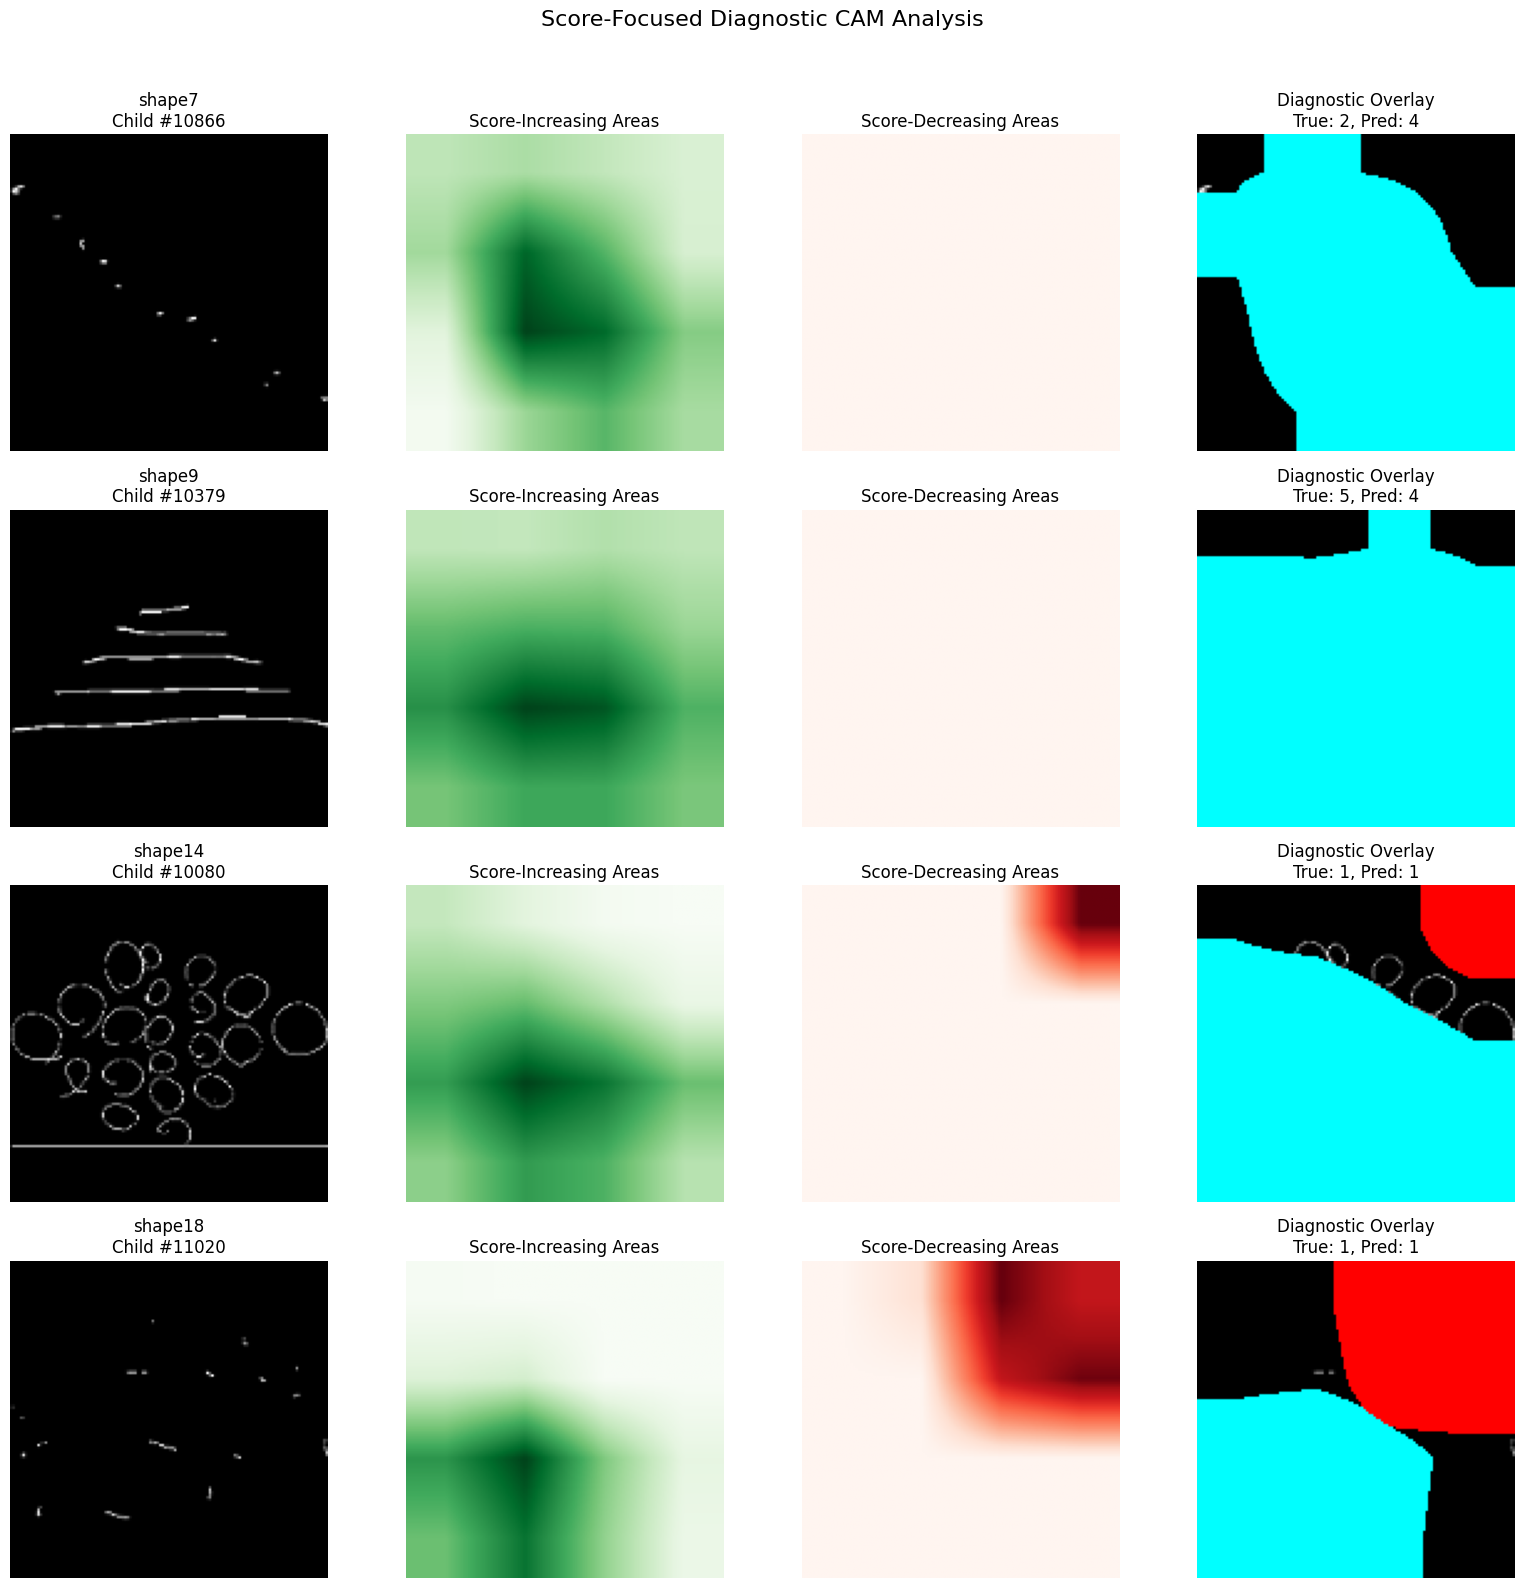

In [30]:
# 1. Bidirectional CAM Calculator
# This function calculates two heatmaps: one for areas that increased the score (positive)
# and one for areas that decreased it (negative). It does this by backpropagating
# from the final score, not an intermediate value.

def compute_bidirectional_cam(model, target_layer, x_child, x_ref, child_disp):
    """
    Computes a Class Activation Map (CAM) that shows both positive (score-increasing)
    and negative (score-decreasing) contributions.
    """
    # Hook storage
    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    # Register hooks on the target layer
    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_full_backward_hook(backward_hook)

    # --- CORE CHANGE: Use the final score as the target ---
    model.zero_grad()
    score = model(x_child, x_ref)
    score.backward()
    # ---------------------------------------------------------

    # Get activations and gradients from the hooks
    acts = activations[0].squeeze(0)  # Shape: [C, H, W]
    grads = gradients[0].squeeze(0) # Shape: [C, H, W]

    # Clean up hooks immediately
    handle_f.remove()
    handle_b.remove()

    # Calculate channel importance weights
    weights = torch.mean(grads, dim=(1, 2)) # Shape: [C]

    # Create the raw CAM by weighting the activation channels
    # This raw map contains both positive and negative values
    raw_cam = torch.zeros(acts.shape[1:], device=acts.device)
    for i, w in enumerate(weights):
        raw_cam += w * acts[i]

    # --- Separate positive (score-increasing) and negative (score-decreasing) parts ---
    cam_pos = F.relu(raw_cam)
    cam_neg = F.relu(-raw_cam)

    # Helper function to process the CAM tensors into normalized numpy arrays
    def process_cam(cam_tensor):
        cam_np = cam_tensor.detach().cpu().numpy()
        cam_np = cv2.resize(cam_np, (child_disp.shape[1], child_disp.shape[0]))
        if cam_np.max() > 0:
            cam_np = cam_np / cam_np.max() # Normalize to [0, 1]
        return cam_np

    cam_pos_norm = process_cam(cam_pos)
    cam_neg_norm = process_cam(cam_neg)

    return cam_pos_norm, cam_neg_norm, score.item()


# 2. Diagnostic Overlay Function
# This function takes the two heatmaps and overlays them on the child's drawing.
# Positive areas are colored cyan, and negative areas are colored red.

def create_diagnostic_overlay(child_disp, cam_pos, cam_neg, threshold=0.3):
    """
    Creates an overlay showing positive contributions in cyan and negative in red.
    """
    # Convert grayscale display image to a 3-channel color image
    overlay = np.stack([child_disp] * 3, axis=-1)

    # Add positive contributions (CYAN) where the CAM value is above the threshold
    mask_pos = cam_pos > threshold
    overlay[mask_pos] = [0, 255, 255] # B, G, R for cyan

    # Add negative contributions (RED) where the CAM value is above the threshold
    mask_neg = cam_neg > threshold
    overlay[mask_neg] = [255, 0, 0]   # B, G, R for red

    return overlay.astype(np.uint8)


# 3. Main Visualization Loop
# This loop iterates through the shapes, selects a random drawing,
# runs the analysis, and plots the results.

shapes = ["shape7", "shape9", "shape14", "shape18"]
fig, axes = plt.subplots(len(shapes), 4, figsize=(16, 16))

# We'll visualize the final convolutional block of the ResNet backbone
TGT_LAYER = model.backbone.layer4[-1]

for idx, shape_name in enumerate(shapes):
    print(f"\nProcessing {shape_name}...")
    sub = df[df["shape_name"] == shape_name]
    if sub.empty: continue

    # FIX: Select a random sample. This avoids the previous KeyError.
    row = sub.sample(1, random_state=SEED + idx).iloc[0]

    # Load and preprocess images for the model and for display
    img_gray = cv2.imread(row.img_path, cv2.IMREAD_GRAYSCALE)
    x_child = val_tf(image=img_gray)["image"].unsqueeze(0).to(device)
    child_disp = smart_center_crop(img_gray)
    child_disp = cv2.resize(child_disp, (IMG_SIZE, IMG_SIZE))

    ref_gray = cv2.imread(row.ref_path, cv2.IMREAD_GRAYSCALE)
    x_ref = val_tf(image=ref_gray)["image"].unsqueeze(0).to(device)
    ref_disp = smart_center_crop(ref_gray)
    ref_disp = cv2.resize(ref_disp, (IMG_SIZE, IMG_SIZE))

    true_label = int(row.label)

    # --- Run the full analysis ---
    cam_pos, cam_neg, score = compute_bidirectional_cam(model, TGT_LAYER, x_child, x_ref, child_disp)
    pred_round = int(np.clip(np.rint(score), 1, 7))
    overlay = create_diagnostic_overlay(child_disp, cam_pos, cam_neg, threshold=0.3)

    # --- Plotting the results ---
    ax = axes[idx]
    ax[0].imshow(child_disp, cmap='gray')
    ax[0].set_title(f"{shape_name}\nChild #{row.child_id}")
    ax[0].axis('off')

    ax[1].imshow(cam_pos, cmap='Greens', vmin=0, vmax=1)
    ax[1].set_title(f"Score-Increasing Areas")
    ax[1].axis('off')

    ax[2].imshow(cam_neg, cmap='Reds', vmin=0, vmax=1)
    ax[2].set_title(f"Score-Decreasing Areas")
    ax[2].axis('off')

    ax[3].imshow(overlay)
    ax[3].set_title(f"Diagnostic Overlay\nTrue: {true_label}, Pred: {pred_round}")
    ax[3].axis('off')

plt.suptitle("Score-Focused Diagnostic CAM Analysis", fontsize=16, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

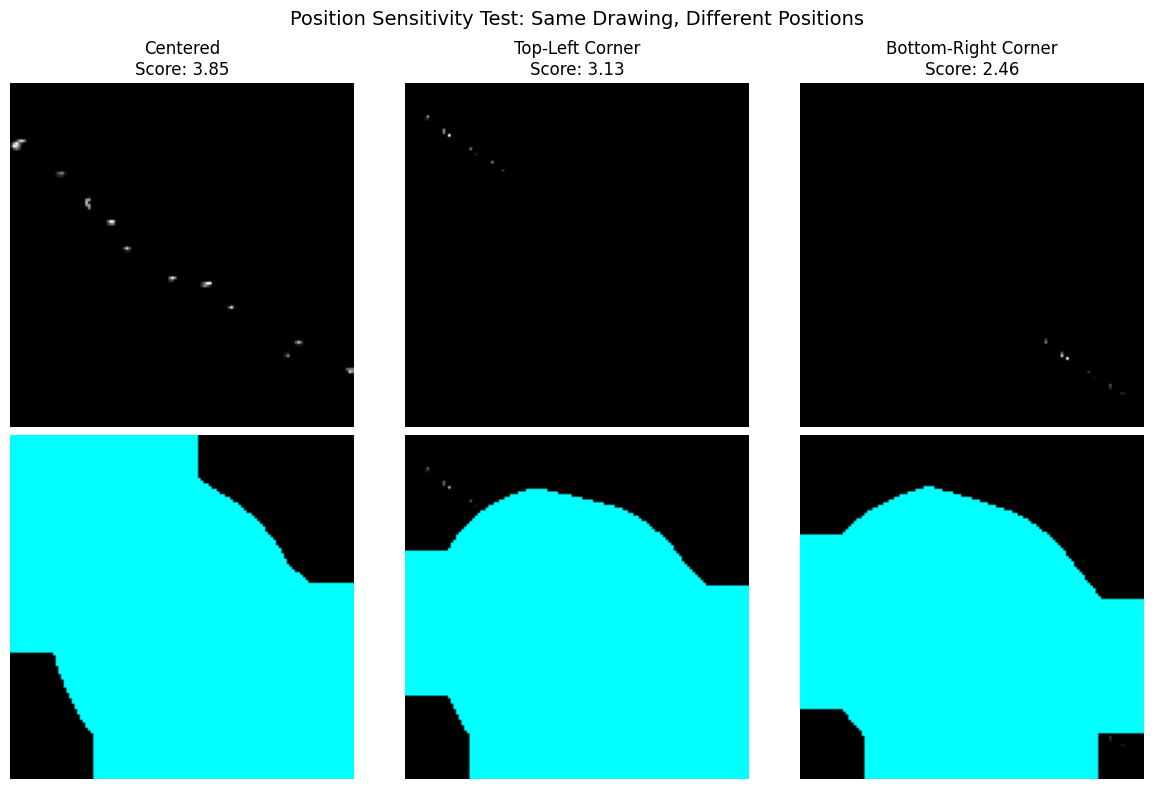

Score differences due to position alone:
  Centered: 3.846
  Top-left: 3.132 (Δ = -0.714)
  Bottom-right: 2.456 (Δ = -1.390)


In [31]:
# Diagnostic Test: Shift the same drawing to different positions
def test_position_sensitivity(model, df, shape_name="shape7"):
    """
    Test if model score changes based on position alone
    """
    # Get a sample
    sub = df[df["shape_name"] == shape_name]
    row = sub.sample(1, random_state=42).iloc[0]

    # Load original image
    img_gray = cv2.imread(row.img_path, cv2.IMREAD_GRAYSCALE)
    ref_gray = cv2.imread(row.ref_path, cv2.IMREAD_GRAYSCALE)

    # Create different versions: centered vs corner
    h, w = 200, 200

    # Version 1: Centered (normal preprocessing)
    img_centered = smart_center_crop(img_gray)
    img_centered = cv2.resize(img_centered, (IMG_SIZE, IMG_SIZE))

    # Version 2: Artificially shift to top-left corner
    canvas_tl = np.zeros((h, w), dtype=np.uint8)
    small = cv2.resize(img_gray, (50, 50))
    canvas_tl[10:60, 10:60] = small
    img_corner = cv2.resize(canvas_tl, (IMG_SIZE, IMG_SIZE))

    # Version 3: Artificially shift to bottom-right corner
    canvas_br = np.zeros((h, w), dtype=np.uint8)
    canvas_br[140:190, 140:190] = small
    img_corner2 = cv2.resize(canvas_br, (IMG_SIZE, IMG_SIZE))

    # Get model predictions for each
    model.eval()
    with torch.no_grad():
        # Preprocess for model
        x_ref = val_tf(image=ref_gray)["image"].unsqueeze(0).to(device)

        x_centered = val_tf(image=img_centered)["image"].unsqueeze(0).to(device)
        x_corner = val_tf(image=img_corner)["image"].unsqueeze(0).to(device)
        x_corner2 = val_tf(image=img_corner2)["image"].unsqueeze(0).to(device)

        score_centered = model(x_centered, x_ref).item()
        score_corner = model(x_corner, x_ref).item()
        score_corner2 = model(x_corner2, x_ref).item()

    # Visualize
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    axes[0, 0].imshow(img_centered, cmap='gray')
    axes[0, 0].set_title(f"Centered\nScore: {score_centered:.2f}")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(img_corner, cmap='gray')
    axes[0, 1].set_title(f"Top-Left Corner\nScore: {score_corner:.2f}")
    axes[0, 1].axis('off')

    axes[0, 2].imshow(img_corner2, cmap='gray')
    axes[0, 2].set_title(f"Bottom-Right Corner\nScore: {score_corner2:.2f}")
    axes[0, 2].axis('off')

    # Run Grad-CAM on each
    for i, (img, x) in enumerate([(img_centered, x_centered),
                                   (img_corner, x_corner),
                                   (img_corner2, x_corner2)]):
        cam_pos, cam_neg, _ = compute_bidirectional_cam(
            model, model.backbone.layer4[-1], x, x_ref, img
        )
        overlay = create_diagnostic_overlay(img, cam_pos, cam_neg, threshold=0.3)
        axes[1, i].imshow(overlay)
        axes[1, i].axis('off')

    plt.suptitle("Position Sensitivity Test: Same Drawing, Different Positions", fontsize=14)
    plt.tight_layout()
    plt.show()

    print(f"Score differences due to position alone:")
    print(f"  Centered: {score_centered:.3f}")
    print(f"  Top-left: {score_corner:.3f} (Δ = {score_corner - score_centered:.3f})")
    print(f"  Bottom-right: {score_corner2:.3f} (Δ = {score_corner2 - score_centered:.3f})")

    return score_centered, score_corner, score_corner2

# Run the test
scores = test_position_sensitivity(model, df)

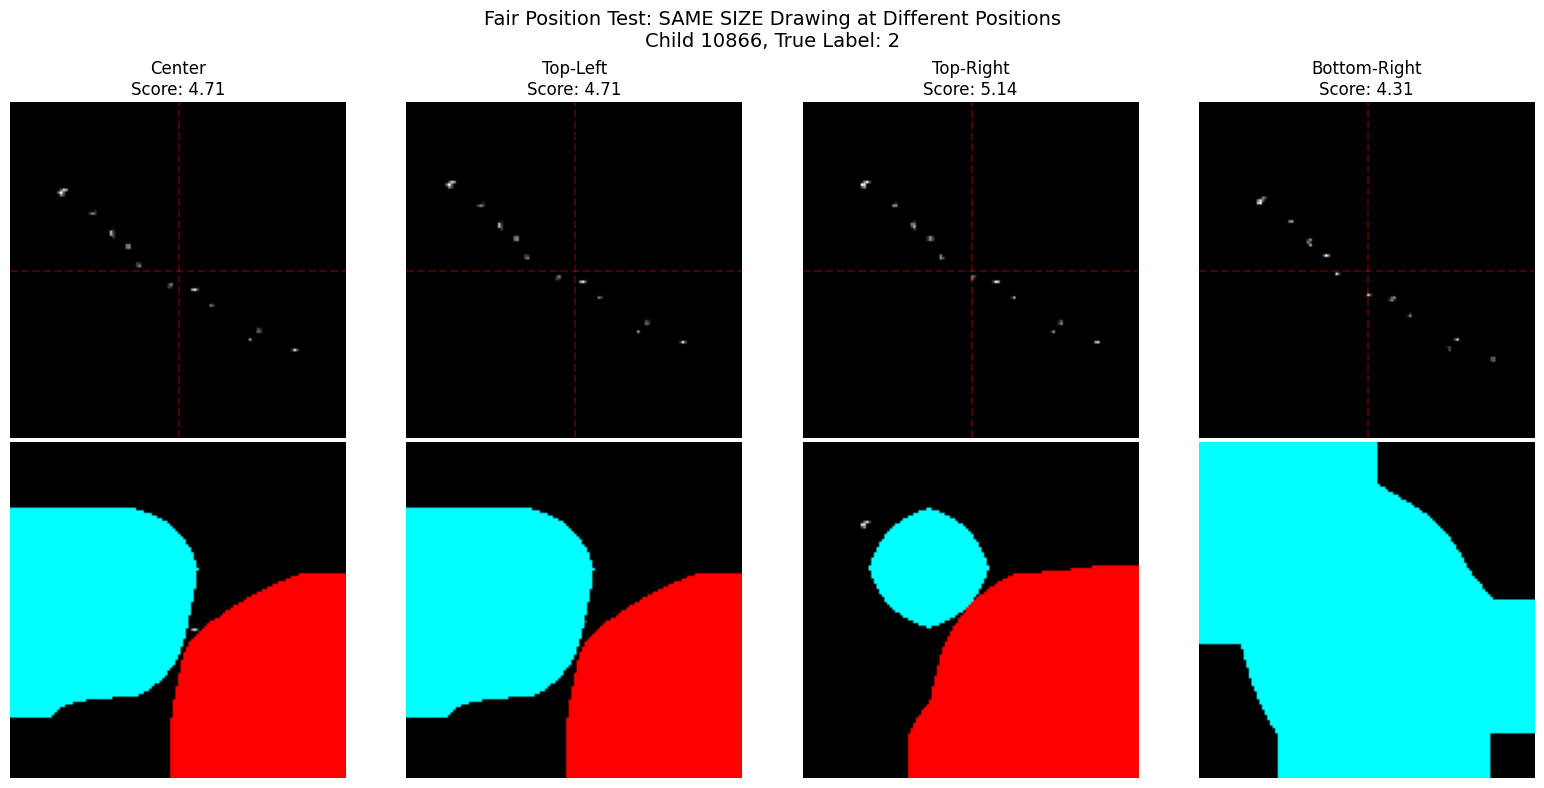


Score Analysis (all drawings are SAME SIZE):
  Center:       4.705 (baseline)
  Top-Left    : 4.705 (Δ = +0.000)
  Top-Right   : 5.139 (Δ = +0.434)
  Bottom-Right: 4.314 (Δ = -0.391)

Range: 5.139 - 4.314 = 0.825
If position doesn't matter, all scores should be similar!


In [39]:
# Better Test: Same size drawing, different positions
def test_position_sensitivity_fair(model, df, shape_name="shape7"):
    """
    Test with SAME SIZE drawing at different positions
    """
    # Get a sample
    sub = df[df["shape_name"] == shape_name]
    row = sub.sample(1, random_state=42).iloc[0]

    # Load original image
    img_gray = cv2.imread(row.img_path, cv2.IMREAD_GRAYSCALE)
    ref_gray = cv2.imread(row.ref_path, cv2.IMREAD_GRAYSCALE)

    # Get the actual drawing content (cropped)
    drawing = smart_center_crop(img_gray, thr=20)
    draw_h, draw_w = drawing.shape

    # Create same-sized canvases with drawing at different positions
    canvas_size = 256  # Larger canvas to allow positioning

    # Version 1: Centered
    canvas_center = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
    y_start = (canvas_size - draw_h) // 2
    x_start = (canvas_size - draw_w) // 2
    y_end = min(y_start + draw_h, canvas_size)
    x_end = min(x_start + draw_w, canvas_size)
    canvas_center[y_start:y_end, x_start:x_end] = drawing[:y_end-y_start, :x_end-x_start]

    # Version 2: Top-left (but same size!)
    canvas_tl = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
    offset = 30  # Small offset from edge
    y_end = min(offset + draw_h, canvas_size)
    x_end = min(offset + draw_w, canvas_size)
    canvas_tl[offset:y_end, offset:x_end] = drawing[:y_end-offset, :x_end-offset]

    # Version 3: Bottom-right (same size!)
    canvas_br = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
    y_start = canvas_size - draw_h - offset
    x_start = canvas_size - draw_w - offset
    y_start = max(0, y_start)
    x_start = max(0, x_start)
    canvas_br[y_start:y_start+draw_h, x_start:x_start+draw_w] = drawing

    # Version 4: Top-right (for variety)
    canvas_tr = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
    x_start = canvas_size - draw_w - offset
    x_start = max(0, x_start)
    canvas_tr[offset:offset+draw_h, x_start:x_start+draw_w] = drawing

    # Resize all to model input size
    img_center = cv2.resize(canvas_center, (IMG_SIZE, IMG_SIZE))
    img_tl = cv2.resize(canvas_tl, (IMG_SIZE, IMG_SIZE))
    img_br = cv2.resize(canvas_br, (IMG_SIZE, IMG_SIZE))
    img_tr = cv2.resize(canvas_tr, (IMG_SIZE, IMG_SIZE))

    # Get predictions
    model.eval()
    with torch.no_grad():
        x_ref = val_tf(image=ref_gray)["image"].unsqueeze(0).to(device)

        scores = {}
        images = {
            'Center': img_center,
            'Top-Left': img_tl,
            'Top-Right': img_tr,
            'Bottom-Right': img_br
        }

        for name, img in images.items():
            x = val_tf(image=img)["image"].unsqueeze(0).to(device)
            scores[name] = model(x, x_ref).item()

    # Visualize
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    positions = ['Center', 'Top-Left', 'Top-Right', 'Bottom-Right']
    imgs = [img_center, img_tl, img_tr, img_br]

    for i, (pos, img) in enumerate(zip(positions, imgs)):
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(f"{pos}\nScore: {scores[pos]:.2f}")
        axes[0, i].axis('off')

        # Add grid lines to show position
        axes[0, i].axhline(y=IMG_SIZE//2, color='r', alpha=0.3, linestyle='--')
        axes[0, i].axvline(x=IMG_SIZE//2, color='r', alpha=0.3, linestyle='--')

        # Grad-CAM
        x = val_tf(image=img)["image"].unsqueeze(0).to(device)
        cam_pos, cam_neg, _ = compute_bidirectional_cam(
            model, model.backbone.layer4[-1], x, x_ref, img
        )
        overlay = create_diagnostic_overlay(img, cam_pos, cam_neg, threshold=0.3)
        axes[1, i].imshow(overlay)
        axes[1, i].axis('off')

    plt.suptitle(f"Fair Position Test: SAME SIZE Drawing at Different Positions\nChild {row.child_id}, True Label: {row.label}", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Print analysis
    print(f"\nScore Analysis (all drawings are SAME SIZE):")
    print(f"  Center:       {scores['Center']:.3f} (baseline)")
    for pos in ['Top-Left', 'Top-Right', 'Bottom-Right']:
        diff = scores[pos] - scores['Center']
        print(f"  {pos:12s}: {scores[pos]:.3f} (Δ = {diff:+.3f})")

    print(f"\nRange: {max(scores.values()):.3f} - {min(scores.values()):.3f} = {max(scores.values()) - min(scores.values()):.3f}")
    print("If position doesn't matter, all scores should be similar!")

    return scores

# Run the fair test
scores = test_position_sensitivity_fair(model, df, shape_name="shape7")